# Moran's I — Spatial Autocorrelation

## Definition
Moran's I measures whether similar values are spatially clustered:

$$I = \frac{N}{\sum_{i}\sum_{j} w_{ij}} \cdot \frac{\sum_{i}\sum_{j} w_{ij}(x_i - \bar{x})(x_j - \bar{x})}{\sum_{i}(x_i - \bar{x})^2}$$

Where:
- $N$ = number of stations
- $x_i$ = KGE at station $i$
- $\bar{x}$ = global mean
- $w_{ij}$ = spatial weight between station $i$ and $j$

## Interpretation
| Value | Meaning |
|-------|---------|
| I ≈ +1 | Strong clustering — similar values are spatially grouped |
| I ≈ 0  | Random spatial distribution — no spatial pattern |
| I ≈ -1 | Dispersion — high and low values alternate |

The **expected value under spatial randomness** is:
$$E[I] = \frac{-1}{N-1} \approx 0 \text{ for large } N$$

Significance is assessed via a **Z-test**:
$$Z = \frac{I - E[I]}{\sqrt{Var[I]}}$$

## Spatial Weights Matrix W
The weights matrix defines who is a "neighbour" of whom.

### Option 1: k-Nearest Neighbours (KNN)
$$w_{ij} = 1 \text{ if } j \in k \text{ nearest neighbours of } i, \text{ otherwise } 0$$

### Option 2: Inverse Distance Weighting
$$w_{ij} = \frac{1}{d_{ij}^\alpha}$$

### Option 3: Distance Threshold
$$w_{ij} = 1 \text{ if } d_{ij} < d_{max}, \text{ otherwise } 0$$

In all cases the matrix is **row-standardised**:
$$w_{ij}^* = \frac{w_{ij}}{\sum_j w_{ij}}$$

## Handling Uneven Spatial Coverage
Our dataset has a classic sampling bias problem: **Europe and North America are densely
sampled, while Africa and Asia are sparse**. This affects Moran's I in two ways:

### Problem 1: Dense clusters dominate
Densely sampled regions (e.g. Europe with 1000+ stations) have many neighbours →
their local pattern dominates the global I value.

### Problem 2: Distance thresholds are not universal
A fixed threshold of e.g. 100 km finds many neighbours in Europe but none in Africa.

### Solution: k-Nearest Neighbours (KNN)
**Every station has exactly k neighbours** — regardless of local sampling density.
This makes comparisons between dense and sparse regions fair and consistent.

A typical choice is k=8 (analogous to the 8 LDD flow directions) or k=10-15.

### Additionally: Local Moran's I (LISA)
Instead of a single global value, **LISA** computes a local I value per station:
$$I_i = \frac{(x_i - \bar{x})}{\sigma^2} \sum_j w_{ij}(x_j - \bar{x})$$

This allows identification of **where** clusters are located (Hot/Cold Spots) —
far more informative than a single global statistic.

## Analysis Strategy
```
Global Moran's I  →  Is there spatial autocorrelation at all?
Local Moran's I   →  Where are the clusters (Hot/Cold Spots)?
Moran Scatterplot →  Which stations are spatial outliers?
```

In [8]:
from libpysal.weights import KNN
from esda.moran import Moran, Moran_Local
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec


### Setup

In [9]:
BASE_FILE = Path.cwd () / "../glofas5_hydrobot.csv"
# Folder with static attributes
DIR_STATIC = Path("/mnt/eos_rw/projects/FLOODS-RIVER/schafti/02_GloFAS_EFAS/GloFAS/GloFASv5/static_maps/GloFASv5_staticmaps_consolidated_March2026/GloFASv5_static_maps_reanalysis/")
# Folder with parameter attributes
DIR_PARS = Path("/mnt/eos_rw/projects/FLOODS-RIVER/schafti/02_GloFAS_EFAS/GloFAS/GloFASv5/static_maps/GloFASv5_parametermaps/")

# Output Dir
DIR_OUT = Path.cwd () / "../results"

# Base File
glofas5_base_info = pd.read_csv(BASE_FILE)

df = glofas5_base_info[["ID", "lon", "lat", "KGEmod"]].dropna().reset_index(drop=True)
coords = df[["lon", "lat"]].values
print(f"Stationen: {len(df)}")


Stationen: 5379


### Calculations

In [10]:
# ─────────────────────────────────────────────
# KNN Gewichtsmatrix — k=10
# Jede Station hat exakt 10 Nachbarn → robust gegen ungleiche Dichte
# ─────────────────────────────────────────────
k = 10
w = KNN.from_array(coords, k=k)
w.transform = "r"  # row-standardisieren

# ─────────────────────────────────────────────
# Global Moran's I
# ─────────────────────────────────────────────
moran = Moran(df["KGEmod"].values, w, permutations=999)

print(f"Global Moran's I : {moran.I:.4f}")
print(f"Expected I       : {moran.EI:.4f}")
print(f"Z-score          : {moran.z_norm:.4f}")
print(f"p-value          : {moran.p_norm:.4f}")
print(f"p-value (perm)   : {moran.p_sim:.4f}  (999 permutations)")

Global Moran's I : 0.4337
Expected I       : -0.0002
Z-score          : 74.8823
p-value          : 0.0000
p-value (perm)   : 0.0010  (999 permutations)


/storage/schafti/conda/schafti_env/lib/python3.11/site-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


In [11]:
# ─────────────────────────────────────────────
# Local Moran's I (LISA)
# ─────────────────────────────────────────────
lisa = Moran_Local(df["KGEmod"].values, w, permutations=999)

# LISA Quadranten:
# HH = High KGE surrounded by High KGE → positive cluster
# LL = Low KGE surrounded by Low KGE   → negative cluster
# HL = High KGE surrounded by Low KGE  → spatial outlier
# LH = Low KGE surrounded by High KGE  → spatial outlier

df["lisa_I"]   = lisa.Is          # lokaler Moran Wert
df["lisa_q"]   = lisa.q           # Quadrant (1=HH, 2=LH, 3=LL, 4=HL)
df["lisa_p"]   = lisa.p_sim       # p-value aus Permutationen
df["lisa_sig"] = lisa.p_sim < 0.05

# Quadranten beschriften
quad_labels = {1: "HH", 2: "LH", 3: "LL", 4: "HL"}
df["lisa_label"] = df["lisa_q"].map(quad_labels)
df.loc[~df["lisa_sig"], "lisa_label"] = "ns"  # nicht signifikant

print(df["lisa_label"].value_counts())

lisa_label
ns    3060
HH    1373
LL     718
LH     125
HL     103
Name: count, dtype: int64


### Plotting

/storage/schafti/conda/schafti_env/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/storage/schafti/conda/schafti_env/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


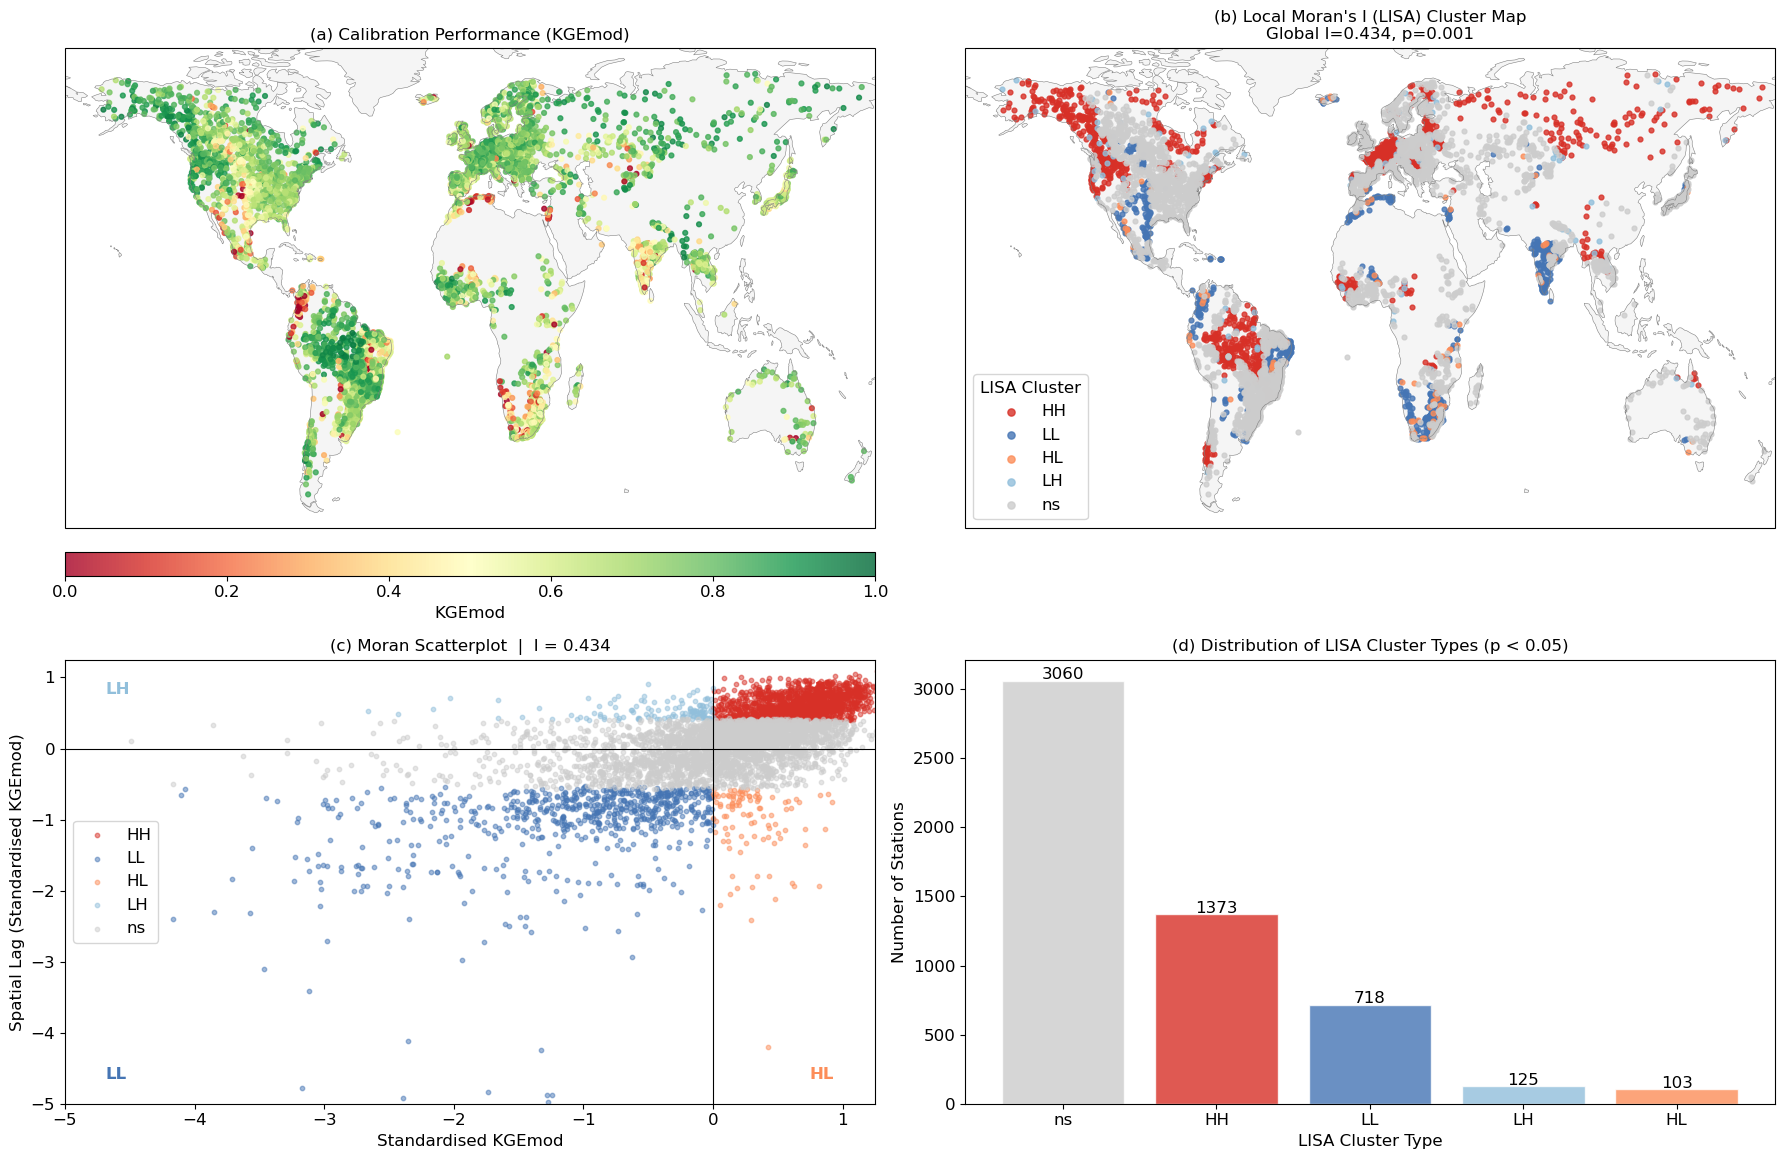

In [37]:
# ─────────────────────────────────────────────
# GLOBALE STYLE VARIABLEN
# ─────────────────────────────────────────────
FS_TITLE    = 12
FS_LABEL    = 12
FS_TICK     = 12
FS_LEGEND   = 12
FS_ANNOT    = 12

fig = plt.figure(figsize=(18, 12))

# Manuelle Positionen: [left, bottom, width, height]
ax1 = fig.add_axes([0.02, 0.54, 0.45, 0.40], projection=ccrs.PlateCarree())
ax2 = fig.add_axes([0.52, 0.54, 0.45, 0.40], projection=ccrs.PlateCarree())
ax3 = fig.add_axes([0.02, 0.06, 0.45, 0.37])
ax4 = fig.add_axes([0.52, 0.06, 0.45, 0.37])

# Aspect ratio fix für beide Karten
ax1.set_aspect("auto")
ax2.set_aspect("auto")

# ── Plot 1: KGE Karte ──
ax1.set_extent([-180, 180, -60, 80], crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.COASTLINE, linewidth=0.4, color="gray")
ax1.add_feature(cfeature.LAND,      facecolor="whitesmoke")
sc1 = ax1.scatter(df["lon"], df["lat"], c=df["KGEmod"],
                  cmap="RdYlGn", s=12, vmin=0, vmax=1, alpha=0.8,
                  transform=ccrs.PlateCarree())
# cbar1 = plt.colorbar(sc1, ax=ax1, orientation="horizontal",
#                      pad=0.02, shrink=0.6, aspect=35)
cax1 = fig.add_axes([0.02, 0.50, 0.45, 0.02])  # [left, bottom, width, height]
cbar1 = plt.colorbar(sc1, cax=cax1, orientation="horizontal")
cbar1.ax.tick_params(labelsize=FS_TICK)
cbar1.set_label("KGEmod", fontsize=FS_LABEL)
ax1.set_title("(a) Calibration Performance (KGEmod)", fontsize=FS_TITLE)

# ── Plot 2: LISA Cluster Map ──
ax2.set_extent([-180, 180, -60, 80], crs=ccrs.PlateCarree())
ax2.add_feature(cfeature.COASTLINE, linewidth=0.4, color="gray")
ax2.add_feature(cfeature.LAND,      facecolor="whitesmoke")

for label, color in quad_colors.items():
    sub = df[df["lisa_label"] == label]
    ax2.scatter(sub["lon"], sub["lat"], c=color, s=12, alpha=0.8,
                label=label, transform=ccrs.PlateCarree())

ax2.legend(title="LISA Cluster", loc="lower left", fontsize=FS_LEGEND,
           title_fontsize=FS_LEGEND, markerscale=1.5, framealpha=0.8)
ax2.set_title(f"(b) Local Moran's I (LISA) Cluster Map\n"
              f"Global I={moran.I:.3f}, p={moran.p_sim:.3f}",
              fontsize=FS_TITLE)

# ── Plot 3: Moran Scatterplot ──
kge_std     = (df["KGEmod"] - df["KGEmod"].mean()) / df["KGEmod"].std()
spatial_lag = lag_spatial(w, kge_std.values)

for label, color in quad_colors.items():
    idx = df["lisa_label"] == label
    ax3.scatter(kge_std[idx], spatial_lag[idx],
                c=color, s=10, alpha=0.5, label=label)

ax3.axhline(0, color="black", linewidth=0.8)
ax3.axvline(0, color="black", linewidth=0.8)
ax3.set_xlabel("Standardised KGEmod", fontsize=FS_LABEL)
ax3.set_ylabel("Spatial Lag (Standardised KGEmod)", fontsize=FS_LABEL)
ax3.set_xlim(-5,1.25)
ax3.set_ylim(-5,1.25)
ax3.tick_params(labelsize=FS_TICK)
ax3.set_title(f"(c) Moran Scatterplot  |  I = {moran.I:.3f}", fontsize=FS_TITLE)
ax3.legend(fontsize=FS_LEGEND)

ax3.text(0.95, 0.95, "HH", transform=ax3.transAxes, ha="right", va="top",
         color=quad_colors["HH"], fontsize=FS_TITLE, fontweight="bold")
ax3.text(0.05, 0.95, "LH", transform=ax3.transAxes, ha="left",  va="top",
         color=quad_colors["LH"], fontsize=FS_TITLE, fontweight="bold")
ax3.text(0.05, 0.05, "LL", transform=ax3.transAxes, ha="left",  va="bottom",
         color=quad_colors["LL"], fontsize=FS_TITLE, fontweight="bold")
ax3.text(0.95, 0.05, "HL", transform=ax3.transAxes, ha="right", va="bottom",
         color=quad_colors["HL"], fontsize=FS_TITLE, fontweight="bold")

# ── Plot 4: LISA Distribution ──
sig_counts = df["lisa_label"].value_counts()
colors_bar = [quad_colors[l] for l in sig_counts.index]
ax4.bar(sig_counts.index, sig_counts.values, color=colors_bar,
        alpha=0.8, edgecolor="white")
ax4.set_xlabel("LISA Cluster Type", fontsize=FS_LABEL)
ax4.set_ylabel("Number of Stations", fontsize=FS_LABEL)
ax4.tick_params(labelsize=FS_TICK)
ax4.set_title("(d) Distribution of LISA Cluster Types (p < 0.05)",
              fontsize=FS_TITLE)
for i, (label, count) in enumerate(sig_counts.items()):
    ax4.text(i, count + 10, str(count), ha="center", fontsize=FS_ANNOT)

plt.savefig(DIR_OUT / "morans_i_analysis.png", dpi=300, bbox_inches="tight")


lisa_label
ns    3060
HH    1373
LL     718
Name: count, dtype: int64


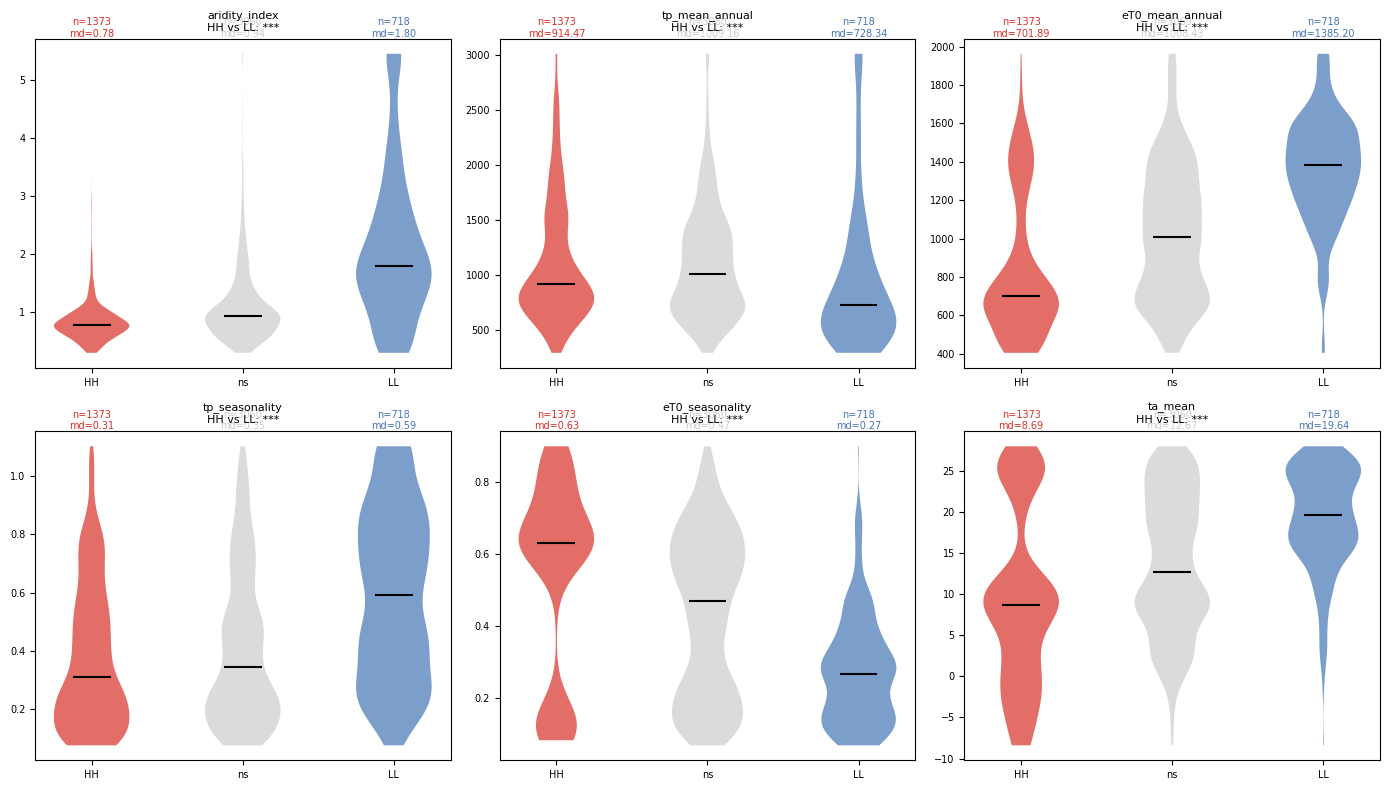

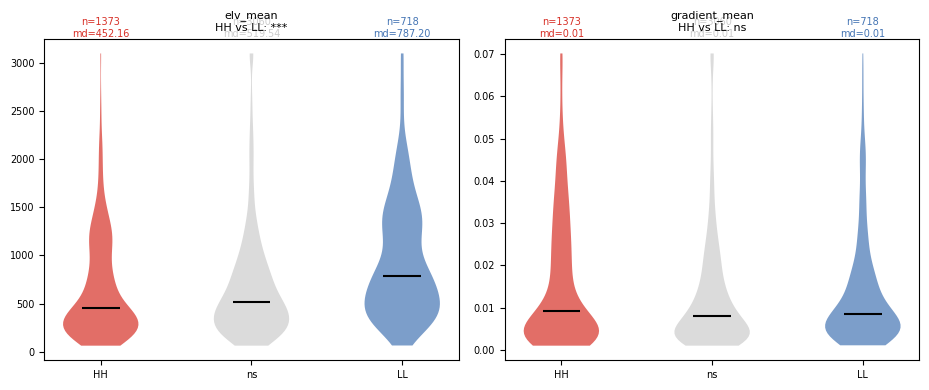

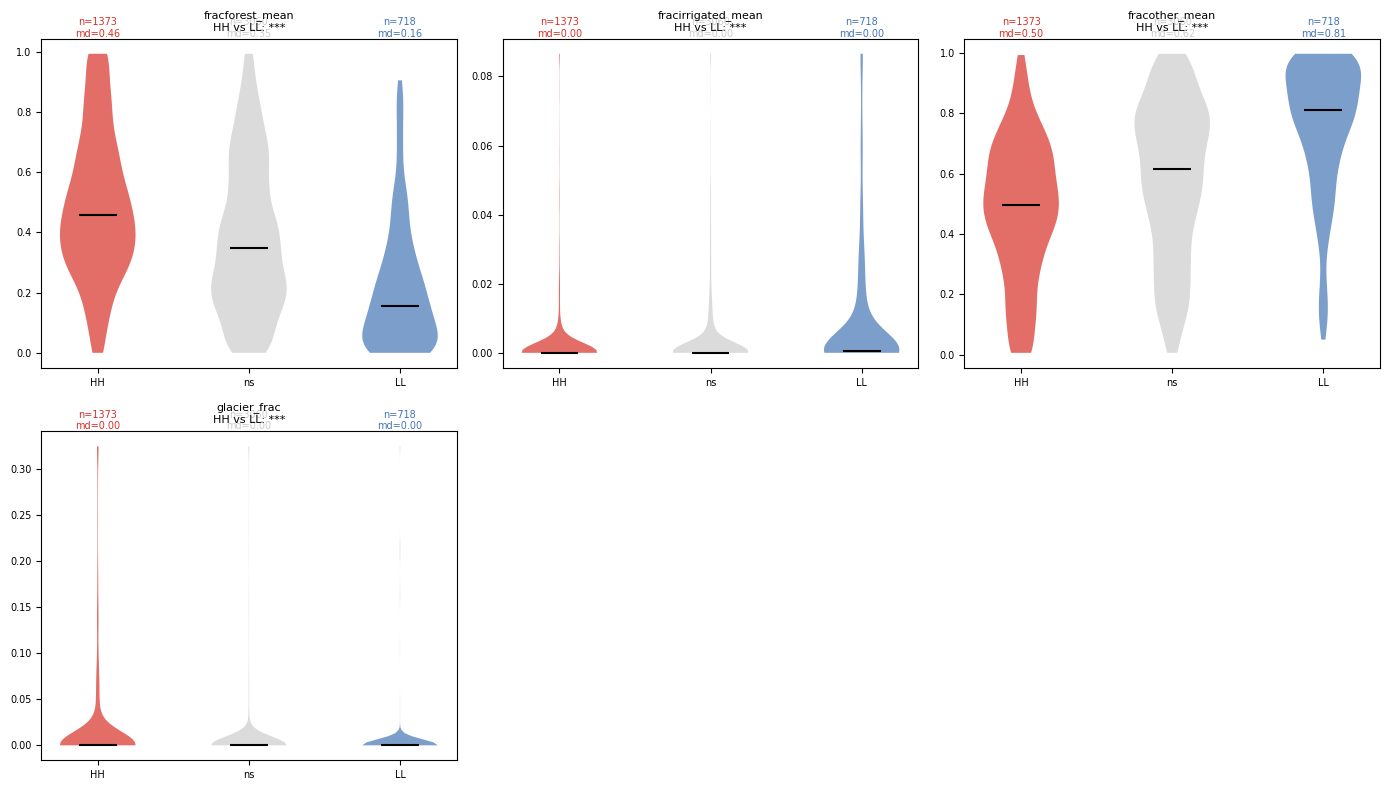

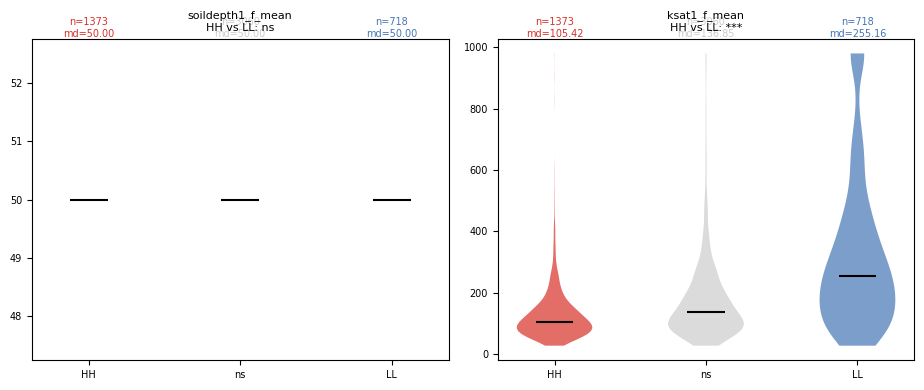

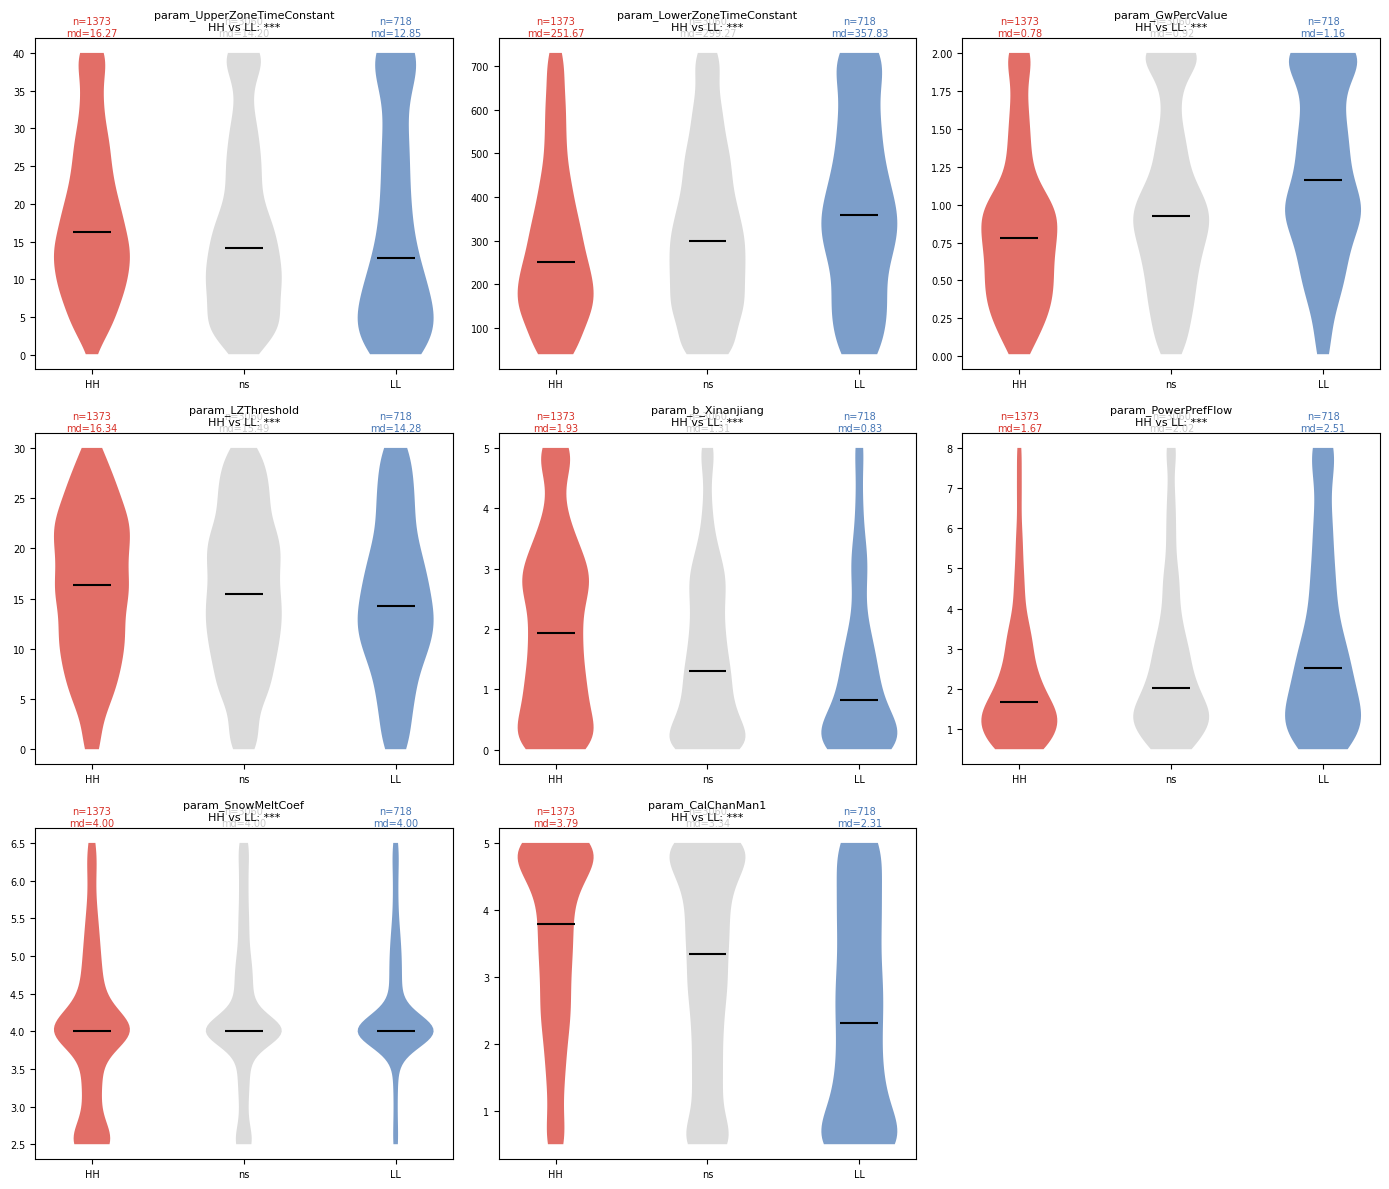

In [41]:
# ─────────────────────────────────────────────
# LL CLUSTER DIAGNOSE
# ─────────────────────────────────────────────

df_diag = glofas5_base_info.copy().reset_index(drop=True)
df_diag = df_diag.merge(df[["ID", "lisa_label"]], on="ID", how="left")
df_diag["lisa_label"] = df_diag["lisa_label"].fillna("ns")
df_diag = df_diag[df_diag["lisa_label"].isin(["HH", "LL", "ns"])].copy()

print(df_diag["lisa_label"].value_counts())

diag_attrs = {
    "Climate"  : ["aridity_index", "tp_mean_annual", "eT0_mean_annual",
                  "tp_seasonality", "eT0_seasonality", "ta_mean"],
    "Terrain"  : ["elv_mean", "gradient_mean"],
    "Land Use" : ["fracforest_mean", "fracirrigated_mean",
                  "fracother_mean", "glacier_frac"],
    "Soil"     : ["soildepth1_f_mean", "ksat1_f_mean"],
    "Params"   : ["param_UpperZoneTimeConstant", "param_LowerZoneTimeConstant",
                  "param_GwPercValue", "param_LZThreshold",
                  "param_b_Xinanjiang", "param_PowerPrefFlow",
                  "param_SnowMeltCoef", "param_CalChanMan1"],
}

cluster_colors = {"HH": "#d73027", "LL": "#4575b4", "ns": "#cccccc"}
cluster_order  = ["HH", "ns", "LL"]

for group_name, attrs in diag_attrs.items():
    n_attrs = len(attrs)
    ncols   = 3
    nrows   = int(np.ceil(n_attrs / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 4))
    axes = axes.flatten()

    for i, attr in enumerate(attrs):
        ax = axes[i]

        data_by_cluster = [
            df_diag[df_diag["lisa_label"] == c][attr].dropna().values
            for c in cluster_order
        ]

        # Clip extreme outliers VOR dem Plot
        q01 = np.nanpercentile(df_diag[attr].dropna(), 1)
        q99 = np.nanpercentile(df_diag[attr].dropna(), 99)
        data_clipped = [np.clip(d, q01, q99) for d in data_by_cluster]

        # Violinplot mit geclippten Daten
        parts = ax.violinplot(data_clipped, positions=[1, 2, 3],
                              showmedians=True, showextrema=False)

        for j, (pc, c) in enumerate(zip(parts["bodies"], cluster_order)):
            pc.set_facecolor(cluster_colors[c])
            pc.set_alpha(0.7)
        parts["cmedians"].set_color("black")
        parts["cmedians"].set_linewidth(1.5)

        # Statistischer Test: LL vs HH Mann-Whitney U
        if len(data_by_cluster[0]) > 0 and len(data_by_cluster[2]) > 0:
            stat, pval = stats.mannwhitneyu(data_by_cluster[0],
                                            data_by_cluster[2],
                                            alternative="two-sided")
            pstar = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"
            ax.set_title(f"{attr}\nHH vs LL: {pstar}", fontsize=8)
        else:
            ax.set_title(attr, fontsize=8)

        # N + Median NACH dem Plot annotieren
        y_top = ax.get_ylim()[1]
        for j, (d, c) in enumerate(zip(data_by_cluster, cluster_order)):
            if len(d) > 0:
                ax.text(j + 1, y_top,
                        f"n={len(d)}\nmd={np.median(d):.2f}",
                        ha="center", va="bottom", fontsize=7,
                        color=cluster_colors[c])

        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels(cluster_order, fontsize=8)
        ax.tick_params(labelsize=7)

    # Leere Subplots ausblenden
    for j in range(n_attrs, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(DIR_OUT / f"lisa_diag_{group_name.lower().replace(' ', '_')}.png",
                dpi=200, bbox_inches="tight")



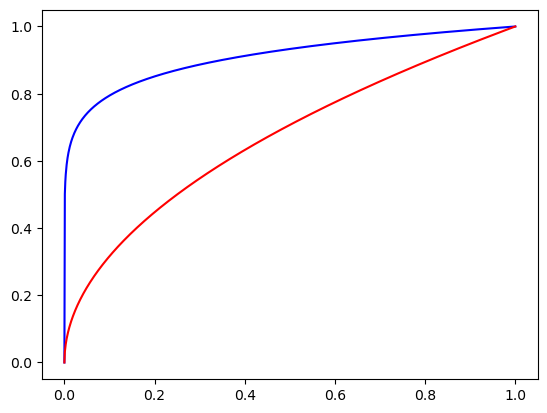

In [76]:
b1 = 0.1
b2 = 0.5
x = np.linspace(0, 1, 1000) 
y1 = ((x)**b1)
y2 = ((x)**b2)

fig, ax = plt.subplots(1,1)
ax.plot(x,y1,c="b")
ax.plot(x,y2,c="r")

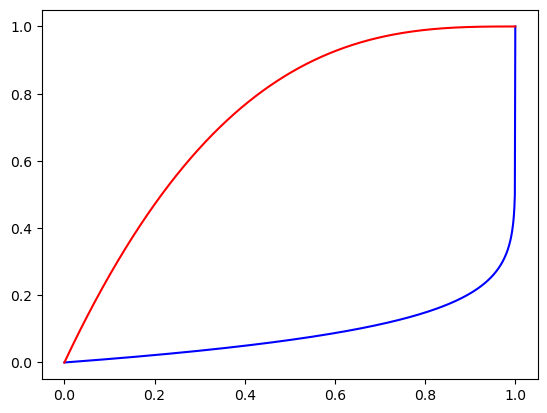

In [85]:

b1 = 0.1
b2 = 2.85
x = np.linspace(0, 1, 1000) 
y1 = 1-((1-x)**b1)
y2 = 1-((1-x)**b2)

fig, ax = plt.subplots(1,1)
ax.plot(x,y1,c="b")
ax.plot(x,y2,c="r")